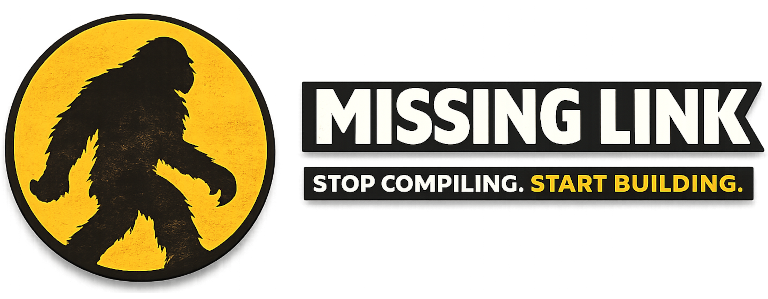

<div style="text-align:center;">
  
  <div style="margin-top:12px; font-size:16px;">
    <b>MissingLink Pre-Built Optimized A100 Colab Python wheels</b><br/>
    ZImage Image Generation Notebook, configuration time savings and out of the box compatibility with default A100 and L4 colab stacks.
  </div>
</div>

The *WAN 2.2 I2V GGUF MissingLink Notebook* lets you **Generate video from image+text** WAN 2.2 is typically extremely challenging to get up and running. But with the MissingLink stable_diffusion_cpp wheel configuration is done in one pip install.

This notebook will let you run wan 2.2 14b in colab, just connect to an L4 or A100 instance and start generating.

1. [Get a Token](https://www.missinglink.build/pricing.html) by signing up for the free trial or purchase a bundle at https://www.missinglink.build this will let you download the optimized A100 Colab wheels. **Replace the ****** text with your token in the cell below.** ( see [Additional Purchase Options](https://www.missinglink.build/pricing.html)

2. **Connect to L4 or A100 Runtime ( Top Right of Colab UI )** you will need to buy credits to run these instances [Buy Colab Credits](https://colab.research.google.com/signup?utm_source=resource_tab&utm_medium=link&utm_campaign=payg_learn_more)

3. Click '**Run All**'

4. Generate an image!

**UI Coming Soon

**Image to video notebook coming soon

*Don't waste your time worrying about configuration or waiting for compilation!*

In [1]:
import os
#MACHINE = "l4" ir "a100"
os.environ['MISSING_LINK_TOKEN'] = "********************************************"
TOKEN = os.environ['MISSING_LINK_TOKEN']
!pip install --no-deps "https://{TOKEN}@missinglink.build/wheel/stable_diffusion_cpp_python-0.4.5-cp312-cp312-linux_x86_64.whl"
!apt-get -y install ffmpeg
!pip install ffmpeg-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 MB 13.3 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


The cell below downloads and loads the model into memory, once loaded you can start generating.

In [5]:
# Colab single cell: WAN 2.2 I2V (GGUF) with stable-diffusion.cpp python bindings
# Paste into one cell and run.
# Put your source image at /content/input.png before running.

import os, sys, math, subprocess

def run(cmd):
    print("+", cmd)
    subprocess.check_call(cmd, shell=True)

!pip install ffmpeg-python huggingface_hub pillow numpy

# --- imports ---
from huggingface_hub import hf_hub_download
from stable_diffusion_cpp import StableDiffusion
from PIL import Image
import numpy as np
import ffmpeg
from IPython.display import Video, display

# =======================
# User settings
# =======================
INPUT_IMAGE_PATH = "/content/lavafloor.png"   # <- upload your image here
PROMPT = (
    "cinematic shot, subtle natural motion, realistic lighting, fixed camera, "
    "high detail, animate the molten lava bubbling"
)
NEGATIVE_PROMPT = (
    "blurry, low quality, overexposed, underexposed, flicker, jitter, warped anatomy, "
    "duplicate objects, text, watermark, logo, artifacts, oversaturated"
)

QUANT = "Q4_K_S"          # try Q3_K_S/Q4_K_S/Q5_K_S depending on RAM/VRAM
FPS = 16
VIDEO_FRAMES = 49         # ~3 seconds at 16 fps
CFG_SCALE = 6.0
I2V_STRENGTH = 0.75       # only used if this wrapper version supports it

# Lighter default for Colab. For a heavier 720p-ish run, change to 1280*720.
TARGET_AREA = 832 * 480

OUTPUT_MP4 = "/content/wan22_i2v_output.mp4"
# =======================

if not os.path.exists(INPUT_IMAGE_PATH):
    raise FileNotFoundError(
        f"{INPUT_IMAGE_PATH} not found. Upload an image to that path first."
    )

# --- model download ---
# IMPORTANT: use the I2V repo, not the T2V repo.
I2V_REPO = "QuantStack/Wan2.2-I2V-A14B-GGUF"
LOW_NOISE_FILE  = f"LowNoise/Wan2.2-I2V-A14B-LowNoise-{QUANT}.gguf"
HIGH_NOISE_FILE = f"HighNoise/Wan2.2-I2V-A14B-HighNoise-{QUANT}.gguf"
VAE_FILE        = "VAE/Wan2.1_VAE.safetensors"

T5_REPO = "city96/umt5-xxl-encoder-gguf"
T5_FILE = "umt5-xxl-encoder-Q8_0.gguf"

low_noise_path  = hf_hub_download(repo_id=I2V_REPO, filename=LOW_NOISE_FILE)
high_noise_path = hf_hub_download(repo_id=I2V_REPO, filename=HIGH_NOISE_FILE)
vae_path        = hf_hub_download(repo_id=I2V_REPO, filename=VAE_FILE)
t5xxl_path      = hf_hub_download(repo_id=T5_REPO, filename=T5_FILE)

print("Downloaded:")
print(" low :", low_noise_path)
print(" high:", high_noise_path)
print(" vae :", vae_path)
print(" t5  :", t5xxl_path)

# --- preserve input aspect ratio while targeting a manageable pixel area ---
img = Image.open(INPUT_IMAGE_PATH).convert("RGB")

def round_to_32(x: float) -> int:
    return max(32, int(round(x / 32.0) * 32))

aspect = img.width / img.height
w = math.sqrt(TARGET_AREA * aspect)
h = TARGET_AREA / w
WIDTH  = round_to_32(w)
HEIGHT = round_to_32(h)

img = img.resize((WIDTH, HEIGHT), Image.Resampling.LANCZOS)
RESIZED_INPUT_PATH = "/content/wan22_i2v_input_resized.png"
img.save(RESIZED_INPUT_PATH)

print(f"Using resolution: {WIDTH}x{HEIGHT}")

# --- load model ---
sd = StableDiffusion(
    diffusion_model_path=low_noise_path,
    high_noise_diffusion_model_path=high_noise_path,
    t5xxl_path=t5xxl_path,
    vae_path=vae_path,
    flow_shift=3.0,
    keep_clip_on_cpu=True,
    diffusion_flash_attn=True,
)

# --- robust i2v call helper ---
# Different wrapper versions may expose slightly different high-level kwarg names.
COMMON_KWARGS = dict(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    width=WIDTH,
    height=HEIGHT,
    cfg_scale=CFG_SCALE,
    sample_method="euler",
    video_frames=VIDEO_FRAMES,
)

def generate_i2v_with_fallbacks(sd_obj, image_path: str, strength: float = 0.75):
    attempts = [
        {"init_image": image_path, "strength": strength},
        {"image": image_path, "strength": strength},
        {"ref_images": [image_path], "strength": strength},
        {"init_image": image_path},
        {"image": image_path},
        {"ref_images": [image_path]},
    ]
    errors = []
    for extra in attempts:
        try:
            print("Trying generate_video with:", list(extra.keys()))
            return sd_obj.generate_video(**COMMON_KWARGS, **extra)
        except TypeError as e:
            errors.append(f"{list(extra.keys())}: {e}")
    raise RuntimeError(
        "Could not find a working image-to-video call signature for this installed "
        "stable-diffusion-cpp-python build.\n\n" + "\n".join(errors)
    )

frames = generate_i2v_with_fallbacks(sd, RESIZED_INPUT_PATH, strength=I2V_STRENGTH)
print(f"Generated {len(frames)} frames")

# --- save mp4 with ffmpeg ---
def save_video_ffmpeg(frames, fps: int, out_path: str) -> None:
    if not frames:
        raise ValueError("No frames returned")
    width, height = frames[0].size
    raw_bytes = b"".join(
        np.array(frame.convert("RGB"), dtype=np.uint8).tobytes()
        for frame in frames
    )
    (
        ffmpeg
        .input(
            "pipe:",
            format="rawvideo",
            pix_fmt="rgb24",
            s=f"{width}x{height}",
            r=fps,
        )
        .output(
            out_path,
            vcodec="libx264",
            pix_fmt="yuv420p",
            r=fps,
            movflags="+faststart",
        )
        .overwrite_output()
        .run(input=raw_bytes)
    )

save_video_ffmpeg(frames, fps=FPS, out_path=OUTPUT_MP4)
print("Saved:", OUTPUT_MP4)
display(Video(OUTPUT_MP4, embed=True))

LowNoise/Wan2.2-I2V-A14B-LowNoise-Q4_K_S(…):   0%|          | 0.00/8.75G [00:00<?, ?B/s]

HighNoise/Wan2.2-I2V-A14B-HighNoise-Q4_K(…):   0%|          | 0.00/8.75G [00:00<?, ?B/s]

VAE/Wan2.1_VAE.safetensors:   0%|          | 0.00/254M [00:00<?, ?B/s]

umt5-xxl-encoder-Q8_0.gguf:   0%|          | 0.00/6.04G [00:00<?, ?B/s]

Downloaded:
 low : /root/.cache/huggingface/hub/models--QuantStack--Wan2.2-I2V-A14B-GGUF/snapshots/6c6717459277b9cd1f72579d78a0fd62a79e57dc/LowNoise/Wan2.2-I2V-A14B-LowNoise-Q4_K_S.gguf
 high: /root/.cache/huggingface/hub/models--QuantStack--Wan2.2-I2V-A14B-GGUF/snapshots/6c6717459277b9cd1f72579d78a0fd62a79e57dc/HighNoise/Wan2.2-I2V-A14B-HighNoise-Q4_K_S.gguf
 vae : /root/.cache/huggingface/hub/models--QuantStack--Wan2.2-I2V-A14B-GGUF/snapshots/6c6717459277b9cd1f72579d78a0fd62a79e57dc/VAE/Wan2.1_VAE.safetensors
 t5  : /root/.cache/huggingface/hub/models--city96--umt5-xxl-encoder-gguf/snapshots/b535255bee98c2b0a59ea7c0ae2dcd0c6657b3b7/umt5-xxl-encoder-Q8_0.gguf


...

Using resolution: 768x512


stable-diffusion.cpp:321  - loading vae from '/root/.cache/huggingface/hub/models--QuantStack--Wan2.2-I2V-A14B-GGUF/snapshots/6c6717459277b9cd1f72579d78a0fd62a79e57dc/VAE/Wan2.1_VAE.safetensors'
model.cpp:373  - load /root/.cache/huggingface/hub/models--QuantStack--Wan2.2-I2V-A14B-GGUF/snapshots/6c6717459277b9cd1f72579d78a0fd62a79e57dc/VAE/Wan2.1_VAE.safetensors using safetensors format
model.cpp:507  - init from '/root/.cache/huggingface/hub/models--QuantStack--Wan2.2-I2V-A14B-GGUF/snapshots/6c6717459277b9cd1f72579d78a0fd62a79e57dc/VAE/Wan2.1_VAE.safetensors', prefix = 'vae.'
model.cpp:1130 - patch_embedding_channels 184320
model.cpp:1130 - patch_embedding_channels 184320
stable-diffusion.cpp:337  - Version: Wan 2.2 I2V 
stable-diffusion.cpp:365  - Weight type stat:                      f32: 75   |     f16: 1388 |    q8_0: 169  |    q4_K: 712  |    q5_K: 88   |    bf16: 194  
stable-diffusion.cpp:366  - Conditioner weight type stat:          f32: 73   |    q8_0: 169  
stable-diffusion

Trying generate_video with: ['init_image', 'strength']
System Info: 
    SSE3 = 1 |     AVX = 1 |     AVX2 = 1 |     AVX512 = 1 |     AVX512_VBMI = 0 |     AVX512_VNNI = 1 |     FMA = 1 |     NEON = 0 |     ARM_FMA = 0 |     F16C = 1 |     FP16_VA = 0 |     WASM_SIMD = 0 |     VSX = 0 | 


ggml_extend.hpp:1759 - wan_vae compute buffer size: 15334.97 MB(VRAM)
stable-diffusion.cpp:2570 - computing vae encode graph completed, taking 14.68s
stable-diffusion.cpp:3927 - encode_first_stage completed, taking 15070 ms
conditioner.hpp:1496 - parse 'cinematic shot, subtle natural motion, realistic lighting, fixed camera, high detail, animate the molten lava bubbling' to [['cinematic shot, subtle natural motion, realistic lighting, fixed camera, high detail, animate the molten lava bubbling', 1], ]
t5.hpp:402  - token length: 512
ggml_extend.hpp:1759 - t5 compute buffer size: 297.00 MB(RAM)
conditioner.hpp:1596 - computing condition graph completed, taking 29874 ms
conditioner.hpp:1496 - parse 'blurry, low quality, overexposed, underexposed, flicker, jitter, warped anatomy, duplicate objects, text, watermark, logo, artifacts, oversaturated' to [['blurry, low quality, overexposed, underexposed, flicker, jitter, warped anatomy, duplicate objects, text, watermark, logo, artifacts, over

Generated 49 frames
Saved: /content/wan22_i2v_output.mp4
